# Makemore: Bigram Language Model

Following Andrej Karpathy's *"The spelled-out intro to language modeling: building makemore"* (Zero to Hero, video 2). We model character sequences in ~32K names using bigrams (P(next char | current char)), first by counting frequencies and normalizing, then by training a single-layer neural network that learns the same distribution via gradient descent. Both approaches converge to the same loss (~2.46 NLL), demonstrating the equivalence between counting and learning.

In [1]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
%matplotlib inline
plt.style.use('dark_background')

In [2]:
# 32K names from Karpathy's makemore repo. Each line is one name.
words = open('../data/names.txt').read().splitlines()
print(f"Total words: {len(words)}")
print(f"Minimum length: {min(len(word) for word in words)}")
print(f"Maximum length: {max(len(word) for word in words)}")

Total words: 32033
Minimum length: 2
Maximum length: 15


In [3]:
# Count bigrams the obvious way: a Python dict mapping (c1, c2) -> count.
# <S> and <E> mark word boundaries so we know which chars start/end words.
bigrams = {}
for word in words:
    chars = ['<S>'] + list(word) + ['<E>']
    for c1, c2 in zip(chars, chars[1:]):
        bigram = (c1, c2)
        bigrams[bigram] = bigrams.get(bigram, 0) + 1

In [4]:
sorted(bigrams.items(), key=lambda item: item[1], reverse=True)[:10]

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963)]

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

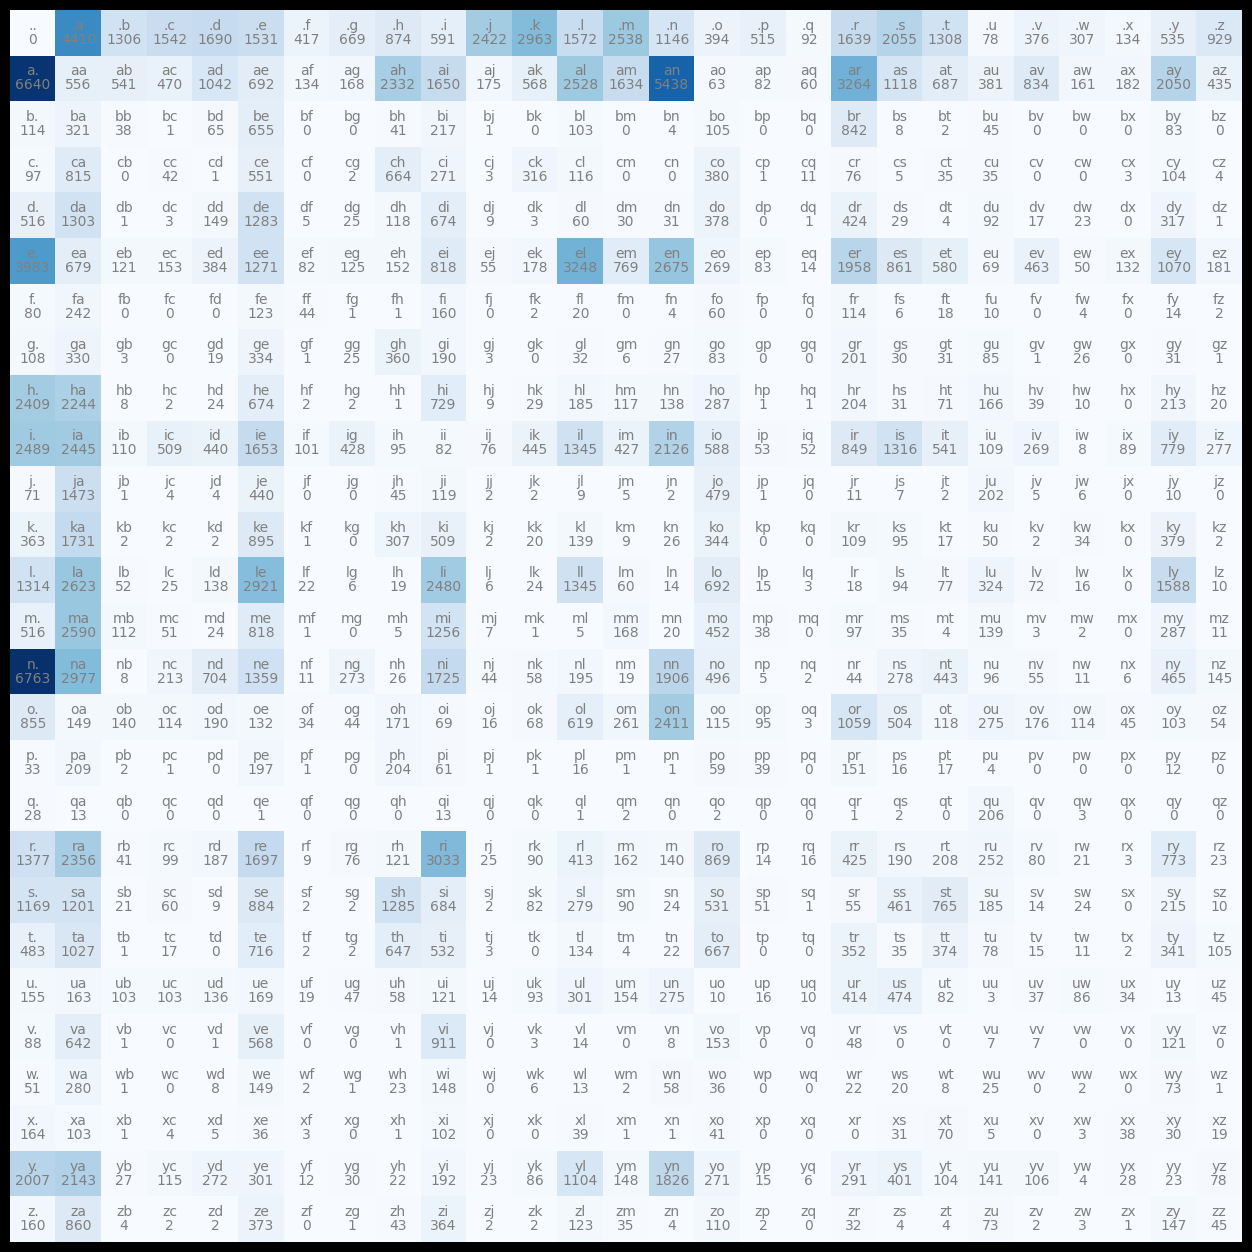

In [5]:
# Same counts, now as a 27x27 tensor (26 letters + '.' as the start/end sentinel).
# Using one '.' for both boundaries keeps the matrix square and simpler than separate <S>/<E>.
bigrams = torch.zeros((27, 27), dtype=torch.int32)

vocab = sorted(list(set(''.join(words))))
stoi = {ch: i + 1 for i, ch in enumerate(vocab)}
stoi['.'] = 0
itos = {i: ch for ch, i in stoi.items()}

for word in words:
    seq = ['.'] + list(word) + ['.']
    for c1, c2 in zip(seq, seq[1:]):
        ix1 = stoi[c1]
        ix2 = stoi[c2]
        bigrams[ix1, ix2] += 1

# Visualize: each cell shows the (c1, c2) pair and the count.
plt.figure(figsize=(16, 16))
plt.imshow(bigrams, cmap='Blues')
for i in range(27):
    for j in range(27):
        label = itos[i] + itos[j]
        plt.text(j, i, label, ha='center', va='bottom', color='gray')
        plt.text(j, i, bigrams[i, j].item(), ha='center', va='top', color='gray')
plt.axis('off')

In [6]:
# Normalize each row to a probability distribution over next chars.
# +1 ('add-one' / Laplace smoothing) avoids zero probabilities for unseen bigrams,
# which would later produce log(0) = -inf when computing NLL.
probabilities = (bigrams + 1).float()
probabilities /= probabilities.sum(1, keepdim=True)

In [7]:
# Sample 10 names by walking the chain: at each step pick the next char from
# P(next | current). torch.multinomial draws an index from the row's probability vector.
index = 0
generator = torch.Generator().manual_seed(2147483647)

for i in range(10):
    out = []    
    while True:
        p = probabilities[index]
        index = torch.multinomial(p, num_samples=1, replacement=True, generator=generator).item()
        out.append(itos[index])
        if index == 0:  # '.' = end of word
            break
    print(f"{i + 1}. {''.join(out)}")    

1. cexze.
2. momasurailezitynn.
3. konimittain.
4. llayn.
5. ka.
6. da.
7. staiyaubrtthrigotai.
8. moliellavo.
9. ke.
10. teda.


### Goal
Maximize likelihood of the data w.r.t. model parameters (statistical modeling)
- Equivalent to maximizing the log likelihood (because log is monotonic)
- Equivalent to minimizing the negative log likelihood
- Equivalent to minimizing the average negative log likelihood

**log(a*b*c) = log(a) + log(b) + log(c)**

In [8]:
# Compute the NLL of the training data under our count-based model.
# This is the baseline any neural net we train should match (or beat).
likelihood = 0.0
count = 0

for word in words:
    chars = ['.'] + list(word) + ['.']
    for c1, c2 in zip(chars, chars[1:]):
        ix1 = stoi[c1]
        ix2 = stoi[c2]

        prob = probabilities[ix1, ix2]
        logprob = torch.log(prob)
        likelihood += logprob
        count += 1

        # print(f'{c1}{c2}: Probability={prob:.4f}, Log Probability={logprob:.4f}')

print(f'Log {likelihood=}')
nll = -likelihood
print(f'{nll=}')
print(f'Normalized {nll/count=}')

Log likelihood=tensor(-559951.5625)
nll=tensor(559951.5625)
Normalized nll/count=tensor(2.4544)


In [9]:
# Pivot: instead of counting + normalizing, train a neural net to learn the same distribution.
# Build (input_char, next_char) pairs as integer indices over the entire dataset.
xs, ys = [], []

for word in words:
    chars = ['.'] + list(word) + ['.']
    for c1, c2 in zip(chars, chars[1:]):
        ix1 = stoi[c1]
        ix2 = stoi[c2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print(f'Number of Examples: {num}')

# Single linear layer: 27 inputs (one-hot char) -> 27 outputs (one logit per next char).
# requires_grad=True so we can backpropagate through these weights.
generator = torch.Generator().manual_seed(2147483647)
weights = torch.randn((27, 27), generator=generator, requires_grad=True)


Number of Examples: 228146


In [22]:
# Gradient descent: forward, compute NLL, backward, update.
# Should converge to roughly the same NLL (~2.46) as the count-based model above.
for k in range(10):
    # Forward pass.
    # One-hot encode each input char: e.g. 'a' (index 1) -> [0,1,0,...,0] of length 27.
    xencoded = F.one_hot(xs, num_classes=27).float()

    # Logits = pre-softmax scores. Interpretable as log-counts.
    logits = xencoded @ weights

    # Softmax: exp() to get pseudo-counts, then normalize across the row to get probs.
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True)

    # NLL loss: pick the probability assigned to the true next char, take -log, average.
    loss = -probs[torch.arange(num), ys].log().mean()
    print(loss.item())

    # Backward pass: zero grads, then accumulate them via .backward().
    weights.grad = None
    loss.backward()

    # Gradient descent step: nudge weights against their gradient.
    weights.data += -50 * weights.grad

2.4690370559692383
2.468891143798828
2.468747615814209
2.46860671043396
2.468468427658081
2.468332529067993
2.4681990146636963
2.4680681228637695
2.4679393768310547
2.4678127765655518
